<Axes: >

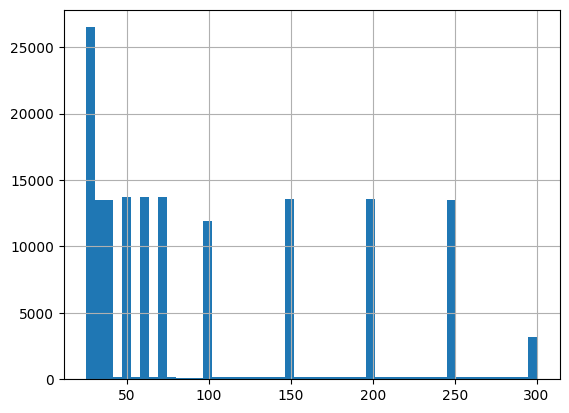

In [4]:
import pandas as pd

df_raw = pd.read_csv(
    "DATA_TP/SweepBcl",
    header=None,
    sep="\t",
)

df = df_raw.iloc[:, [0, 1, 2, 12, 13]].set_axis(['step', 'temp', 'mag', 'vxx', 'vxy'], axis=1)
df.temp.hist(bins=50)

In [62]:
from sklearn import metrics
from sklearn.cluster import DBSCAN


clustering = DBSCAN(eps=1, min_samples=1000).fit(df.temp.values.reshape(-1, 1))

In [63]:
print(len(set(clustering.labels_)))

df['temp_cluster'] = clustering.labels_

13


<Axes: xlabel='mag'>

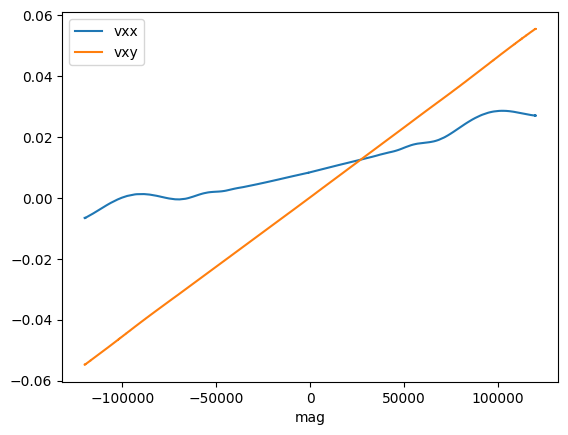

In [76]:
df[df.temp_cluster == 4].plot.line(x="mag", y=["vxx", "vxy"])

t0=np.float64(24.9944), t1=np.float64(26.24412)


<Axes: xlabel='mag'>

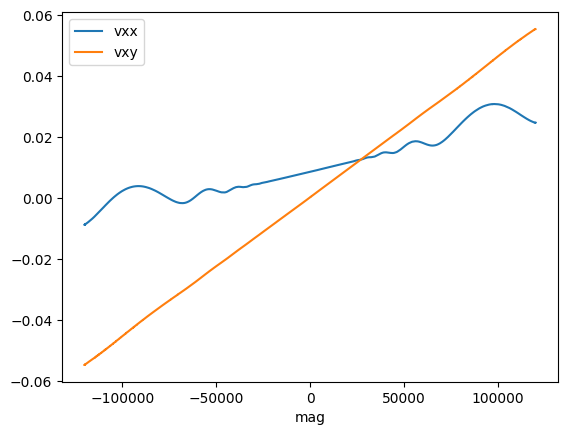

In [13]:
t0 = df.temp.min()
t1 = t0 * 1.05

print(f"{t0=}, {t1=}")

df_0 = df[df.temp < t1]
df_0.plot.line(x="mag", y=["vxx", "vxy"])

In [19]:
import numpy as np

def process_measurement(B, Vxx, Vxy):
    a_vxx0 = Vxx + np.interp(B * -1, B, Vxx)
    b_vxy0 = Vxx - np.interp(B * -1, B, Vxx)
    c_vxx0 = Vxy + np.interp(B * -1, B, Vxy)
    d_vxy0 = Vxy - np.interp(B * -1, B, Vxy)

    return a_vxx0/2, b_vxy0/2, c_vxx0/2, d_vxy0/2

def density_from_Vh(Vh, B, I, e):
    """
    Vh: Tension de Hall (V)
    B: Champ magnetique (T)
    I: Intensité (A)
    e: epaisseur (m)
    """
    q = 1.6E-19         # charge elementaire (C)

    Vh = np.array(Vh)
    B = np.array(B)

    coeffs = np.polyfit(B, Vh, 1)
    slope = coeffs[0]
    intercept = coeffs[1]

    n = I / (q * e * slope)

    print("Slope dVh/dB =", slope, "V/T")
    print("Densité n =", n, "m^-3")

    return n, slope

def full_process(df, t0, t1):
    pass

In [20]:
measurements = process_measurement(df_0.mag, df_0.vxx, df_0.vxy)
df_0["a_vxx0"] = measurements[0]
df_0["b_vxy0"] = measurements[1]
df_0["c_vxx0"] = measurements[2]
df_0["d_vxy0"] = measurements[3]

<Axes: xlabel='mag'>

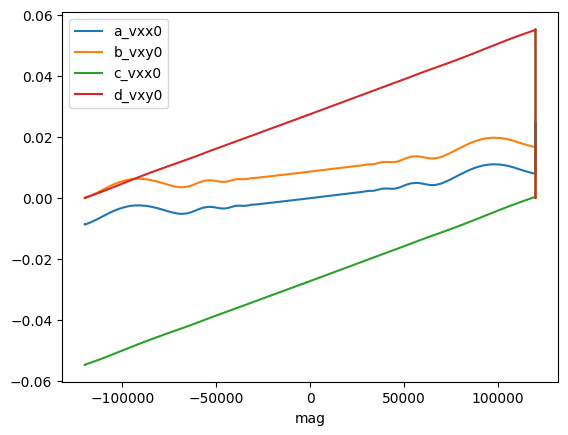

In [21]:
df_0.plot.line(x="mag", y=[
    "a_vxx0",
    "b_vxy0",
    "c_vxx0",
    "d_vxy0",
])

In [23]:
I = 2 *1E-3
Umag = 1E-4
Uv = 1/100

e = 0.5e-3                 # epaisseur (m)

Vh = np.array(df_0["d_vxy0"] * Uv)
B = np.array(df_0["mag"] * Umag)

n , slope = density_from_Vh(Vh, B, I, e)

Slope dVh/dB = 2.209969146221447e-05 V/T
Densité n = 1.1312375126478307e+24 m^-3


In [40]:
tau = 100

(np.interp(0, df_0.mag, df_0.vxx), np.interp(0, df_0.mag, df_0.c_vxx0), np.interp(0, df_0.mag, df_0.a_vxx0))

(np.float64(-0.00872046), np.float64(-0.0547335), np.float64(-0.00872046))

In [44]:

e = 0.5e-3                 # epaisseur (m)
la = 1.46e-3            # largeur (m)
lo = 5.36e-3            # longueur (m)
q = 1.6E-19         # charge elementaire (C)

Vxx0 = 0.00872046 * Uv
S = e * la

rhoxx = (Vxx0 / I) * (S / lo)
rhoxx

5.938372947761194e-06

In [46]:
mu = 1 / (rhoxx * n * q)
mu

np.float64(0.9303765381789554)